# **Terrestrial Planet Transit Spectroscopy** #

In [1]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_E, M_E

#***** Define stellar properties *****#

R_s = 0.11697*R_Sun   # Stellar radius (m)
T_s = 2559.0          # Stellar effective temperature (K)
Met_s = 0.04          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.21        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'TRAPPIST-1e'  # Planet name used for plots, output files etc.

R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

/home/ers1n25/miniconda3/envs/poseidon/lib/python3.11/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_1 = 'Modern_Earth'   # First model
model_name_2 = 'Archean_Earth'  # Second model

bulk_species = ['N2']                                      # For terrestrial planets, only the single most abundant gas should be provided here
param_species = ['O2', 'CO2', 'CH4', 'H2O', 'O3', 'N2O']   # Less abundant chemical species (same species for both model)

# Create the model objects
model_1 = define_model(model_name_1, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_2 = define_model(model_name_2, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)

#***** Create model pressure grid (same for both models) *****#

# Specify the pressure grid of the atmosphere
P_min = 1.0e-7    # 0.1 ubar
P_max = 10.0      # 10 bar (you can extend the atmosphere deeper than the surface)
N_layers = 100    # 100 layers

P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Add the surface pressure
P_surf = 1.0      # Effectively acts as a cloud deck opaque at all wavelengths

# Specify the reference pressure and radius
P_ref = P_surf    # We'll set the reference pressure at the surface
R_p_ref = R_p     # Radius at reference pressure

In [3]:
from POSEIDON.utility import read_PT_file

# Specify location of the P-T profile file
PT_file_dir = './POSEIDON/reference_data/models/TRAPPIST-1e'
PT_file_name_1 = 'TRAPPIST-1e_1.0bar_100xCO2_Modern_PT.txt'
PT_file_name_2 = 'TRAPPIST-1e_1.0bar_100xCO2_Archean_PT.txt'

# Read the P-T profile files
T_Modern = read_PT_file(PT_file_dir, PT_file_name_1, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Archean = read_PT_file(PT_file_dir, PT_file_name_2, P, skiprows = 1,
                        P_column = 2, T_column = 3)

In [4]:
from POSEIDON.utility import read_chem_file

# Specify location of the composition file
chem_file_dir = './POSEIDON/reference_data/models/TRAPPIST-1e'
chem_file_name_1 = 'TRAPPIST-1e_1.0bar_100xCO2_Modern_chem.txt'
chem_file_name_2 = 'TRAPPIST-1e_1.0bar_100xCO2_Archean_chem.txt'

chem_species_file = ['N2', 'O2', 'O3', 'H2O', 'CH4', 'N2O', 'CO2', 'CO']  # Same ordering for both files

# Read the composition files
X_Modern = read_chem_file(chem_file_dir, chem_file_name_1, P, chem_species_file,
                          chem_species_in_model = model_1['chemical_species'],
                          skiprows = 1)
X_Archean = read_chem_file(chem_file_dir, chem_file_name_2, P, chem_species_file,
                           chem_species_in_model = model_2['chemical_species'],
                           skiprows = 1)

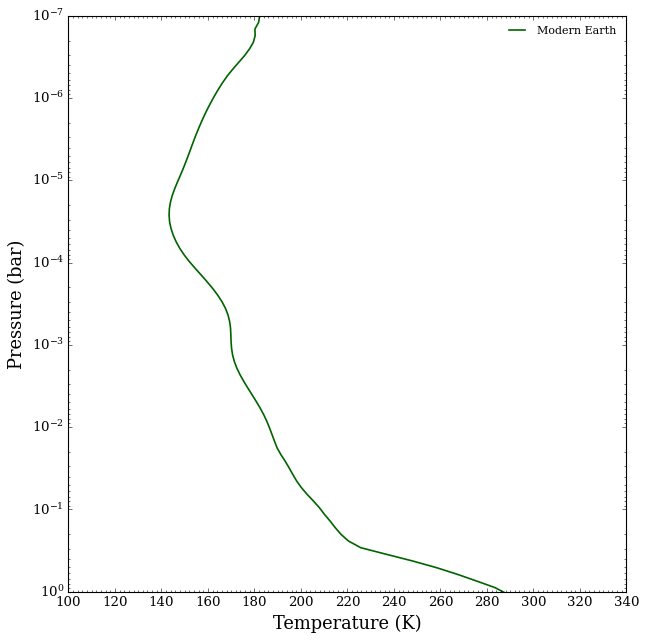

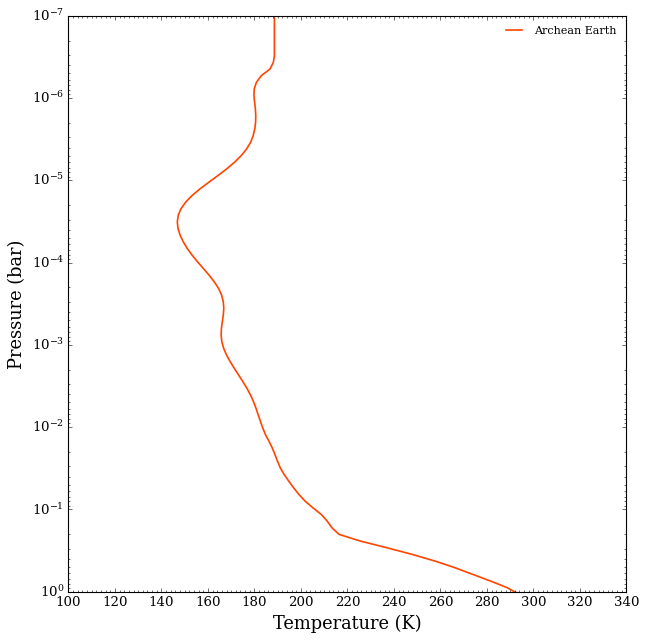

In [5]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem

# Generate the atmospheres
atmosphere_1 = make_atmosphere(planet, model_1, P, P_ref, R_p_ref,
                               T_input = T_Modern, X_input = X_Modern,    # Provide T and X directly here
                               P_surf = P_surf)                           # Also provide the surface pressure
atmosphere_2 = make_atmosphere(planet, model_2, P, P_ref, R_p_ref,
                               T_input = T_Archean, X_input = X_Archean,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure

#***** Produce plots of atmospheric properties *****#

# Compare the P-T profiles first
fig_PT_1 = plot_PT(planet, model_1, atmosphere_1, T_min = 100, T_max = 340,       # This demonstrates several plot customisation options
                   log_P_max = np.log10(P_surf), PT_label = 'Modern Earth',
                   legend_location = 'upper right', colour = 'darkgreen')
fig_PT_2 = plot_PT(planet, model_2, atmosphere_2, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Archean Earth',
                   legend_location = 'upper right', colour = 'orangered')

#fig_geom_1 = plot_geometry(planet, star, model_1, atmosphere_1)   # This figure looks a little boring for a (tiny) Earth-like atmosphere!

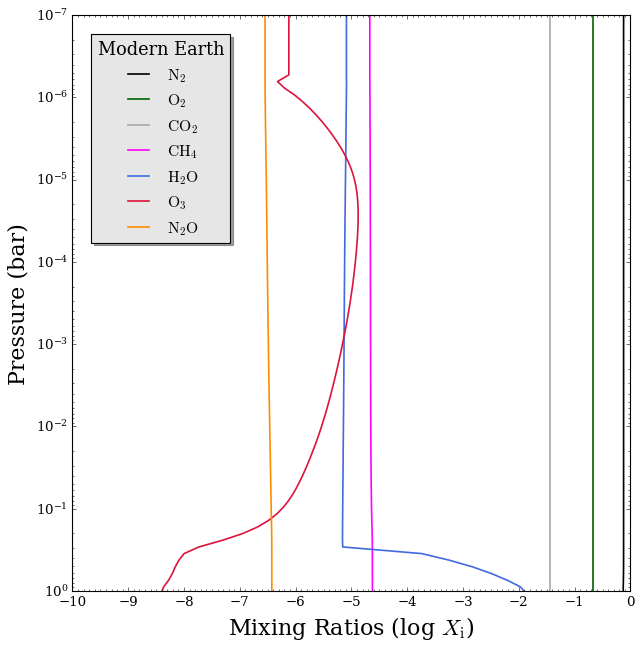

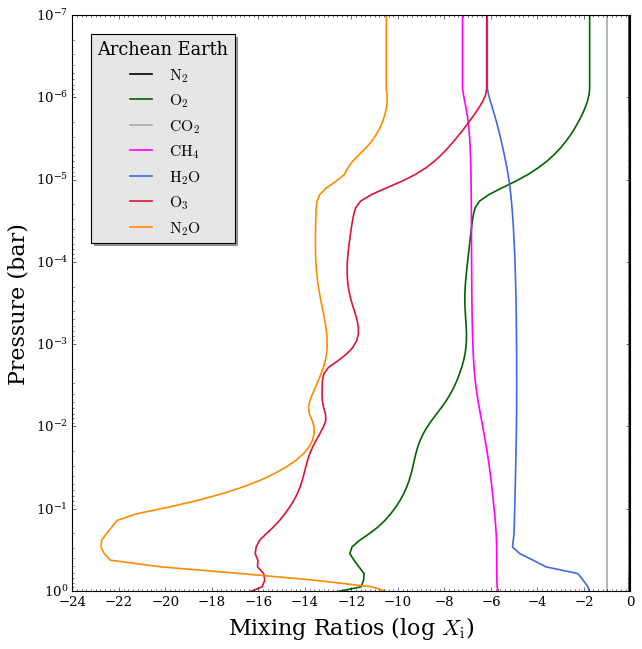

In [6]:
# Compare the mixing ratio profiles
fig_chem_1 = plot_chem(planet, model_1, atmosphere_1, log_P_max = np.log10(P_surf),
                       legend_title = 'Modern Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',   # Here you can override the default colours
                                      'royalblue', 'crimson', 'darkorange'])
fig_chem_2 = plot_chem(planet, model_2, atmosphere_2, log_P_max = np.log10(P_surf),
                       legend_title = 'Archean Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                       'royalblue', 'crimson', 'darkorange'])

# **Compute Transmission Spectra for TRAPPIST-1e** #

In [7]:
from POSEIDON.core import read_opacities, wl_grid_constant_R

#***** Wavelength grid *****#

wl_min = 0.6      # Minimum wavelength (um)
wl_max = 14.0     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the TRAPPIST-1e P-T profile
T_fine_max = 300     # 300 K upper limit covers the TRAPPIST-1e P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 0.0    # 1 bar is the surface pressure, so no need to go deeper
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model_1, wl, opacity_treatment, T_fine, log_P_fine,
                      opacity_database = 'Temperate')

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
O2-O2 done
O2-CO2 done
O2-N2 done
O2 done
CO2 done
CH4 done
H2O done
O3 done
N2O done
Opacity pre-interpolation complete.


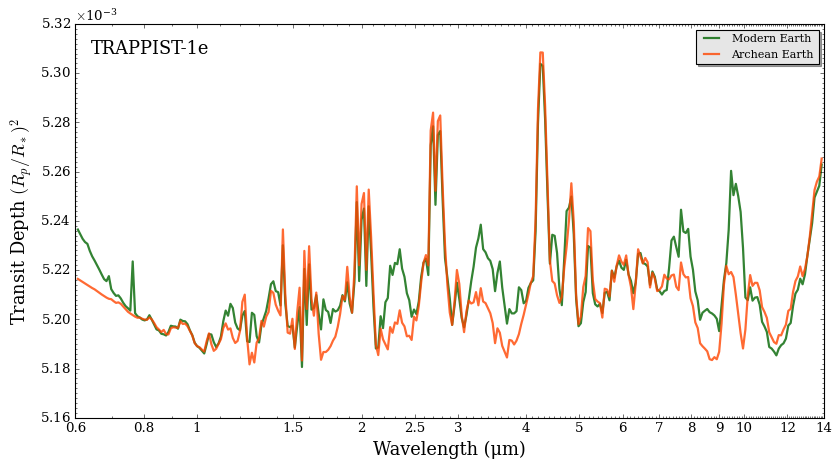

In [8]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate our first transmission spectrum
spectrum_Modern = compute_spectrum(planet, star, model_1, atmosphere_1, opac, wl,
                                   spectrum_type = 'transmission')
spectrum_Archean = compute_spectrum(planet, star, model_2, atmosphere_2, opac, wl,
                                    spectrum_type = 'transmission')

spectra = []   # Empty plot collection

# Add the two model spectra to the plot collection object
spectra = plot_collection(spectrum_Modern, wl, collection = spectra)
spectra = plot_collection(spectrum_Archean, wl, collection = spectra)

# Produce figure and save to file
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        y_min = 5.16e-3, y_max = 5.32e-3,
                        spectra_labels = ['Modern Earth', 'Archean Earth'],
                        colour_list = ['darkgreen', 'orangered'],
                        figure_shape = 'wide')   # Switch to a 'wide' format (16:9) for better viewing a long wavelength range